# 02. Modeling

## Machine Learning Regression Model for Marketing Revenue Prediction

### Project Overview

This notebook covers the Machine Learning modeling phase of the project.

The objective is to build, evaluate, and compare regression models capable of predicting the revenue generated by digital marketing campaigns.

Following the Dataset Assessment and Exploratory Data Analysis (EDA), this notebook focuses on transforming the prepared dataset into a predictive machine learning solution using Scikit-learn.

### Objectives

The main objectives of this notebook are:

- Prepare the dataset for machine learning.
- Define the target and predictor variables.
- Build a preprocessing pipeline.
- Train and compare multiple regression models.
- Evaluate model performance using regression metrics.
- Select the best-performing model.
- Interpret the model from both technical and business perspectives.

## 1. Environment Setup

## Objective

This section imports the required Python libraries and configures the notebook environment for the modeling phase.

The imported packages support:

- Data manipulation
- Data visualization
- Machine Learning
- Model evaluation
- Preprocessing pipelines

In [46]:
# =====================================
# Data Manipulation
# =====================================

import numpy as np
import pandas as pd

# =====================================
# Data Visualization
# =====================================

import matplotlib.pyplot as plt

# =====================================
# Machine Learning
# =====================================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Models

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

# Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================
# Notebook Configuration
# =====================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# =====================================
# Data Visualization
# =====================================

import matplotlib.pyplot as plt

# =====================================
# Machine Learning
# =====================================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Models

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

# Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================
# Notebook Configuration
# =====================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# 2. Load Dataset

## Objective

The purpose of this section is to load the dataset that will be used throughout the modeling process.

A quick verification of the dataset dimensions and structure is performed before preparing the data for machine learning.

In [47]:
df = pd.read_csv("../data/digital_marketing_dataset_30k.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (30000, 35)


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,1,Yes,Iraq,Tier 1,Travel_SkyTrip,Brand,TikTok,In-Feed,Awareness,Reach,Product Launch,C30853,Travel_SkyTrip_Product Launch_Awareness_TikTok...,AG412799,Product Launch_In-Feed_6,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,0,No,Morocco,Tier 1,FMCG_Foodies,Brand,Meta,Feed,Awareness,Video Views,Seasonal,C49194,FMCG_Foodies_Seasonal_Awareness_Meta_Apr_2025,AG863446,Seasonal_Feed_42,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,0,No,United Arab Emirates,Tier 1,Ecom_FashionCo,Brand,Google Display,Display,Conversion,Sales,UGC,C54438,Ecom_FashionCo_UGC_Conversion_Google Display_D...,AG769411,UGC_Display_2,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,0,No,KSA,Tier 1,Ecom_ElectroHub,Brand,Snapchat,Stories,Consideration,Traffic,Educational,C60684,Ecom_ElectroHub_Educational_Consideration_Snap...,AG131656,Educational_Stories_49,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,0,No,Bahrain,Tier 3,FMCG_Foodies,Brand,Meta,Reels,Awareness,Reach,Retargeting,C57210,FMCG_Foodies_Retargeting_Awareness_Meta_Apr_2024,AG633873,Retargeting_Reels_37,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160


In [48]:
df.columns.tolist()

['date',
 'year',
 'month',
 'month_name',
 'week',
 'day_of_week',
 'post_hour',
 'season',
 'is_holiday',
 'is_holiday (text)',
 'is_weekend',
 'is_weekend (text)',
 'country',
 'market_tier',
 'account',
 'account_type',
 'platform',
 'placement',
 'funnel_stage',
 'objective',
 'theme',
 'campaign_id',
 'campaign_name',
 'ad_group_id',
 'ad_group_name',
 'ad_id',
 'ad_name',
 'spend',
 'impressions',
 'reach',
 'frequency',
 'clicks',
 'conversions',
 'revenue',
 'video_views']

# 3. Load Dataset

## Objective

Load the cleaned dataset generated during the Dataset Assessment and EDA phases.

The objective of this section is to import the dataset that will be used throughout the modeling process and perform a quick verification of its structure before preparing it for machine learning.

### Contents

- Read CSV file
- Verify dataset dimensions
- Display the first observations
- Inspect column names

In [49]:
# =====================================
# Load Dataset
# =====================================

df = pd.read_csv("../data/digital_marketing_dataset_30k.csv")

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (30000, 35)


,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,1,Yes,Iraq,Tier 1,Travel_SkyTrip,Brand,TikTok,In-Feed,Awareness,Reach,Product Launch,C30853,Travel_SkyTrip_Product Launch_Awareness_TikTok...,AG412799,Product Launch_In-Feed_6,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,0,No,Morocco,Tier 1,FMCG_Foodies,Brand,Meta,Feed,Awareness,Video Views,Seasonal,C49194,FMCG_Foodies_Seasonal_Awareness_Meta_Apr_2025,AG863446,Seasonal_Feed_42,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,0,No,United Arab Emirates,Tier 1,Ecom_FashionCo,Brand,Google Display,Display,Conversion,Sales,UGC,C54438,Ecom_FashionCo_UGC_Conversion_Google Display_D...,AG769411,UGC_Display_2,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,0,No,KSA,Tier 1,Ecom_ElectroHub,Brand,Snapchat,Stories,Consideration,Traffic,Educational,C60684,Ecom_ElectroHub_Educational_Consideration_Snap...,AG131656,Educational_Stories_49,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,0,No,Bahrain,Tier 3,FMCG_Foodies,Brand,Meta,Reels,Awareness,Reach,Retargeting,C57210,FMCG_Foodies_Retargeting_Awareness_Meta_Apr_2024,AG633873,Retargeting_Reels_37,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160


In [50]:
# Display column names

df.columns.tolist()

['date',
 'year',
 'month',
 'month_name',
 'week',
 'day_of_week',
 'post_hour',
 'season',
 'is_holiday',
 'is_holiday (text)',
 'is_weekend',
 'is_weekend (text)',
 'country',
 'market_tier',
 'account',
 'account_type',
 'platform',
 'placement',
 'funnel_stage',
 'objective',
 'theme',
 'campaign_id',
 'campaign_name',
 'ad_group_id',
 'ad_group_name',
 'ad_id',
 'ad_name',
 'spend',
 'impressions',
 'reach',
 'frequency',
 'clicks',
 'conversions',
 'revenue',
 'video_views']

# 4. Dataset Preparation

## Objective

Prepare the dataset for Machine Learning.

Contents:

- Define target variable
- Separate X and y
- Identify numerical features
- Identify categorical features
- Detect possible data leakage
- Remove unnecessary variables

In [51]:
# =====================================
# Dataset Preparation
# =====================================

# Target variable
target = "revenue"

# Columns excluded from modeling
excluded_columns = [
    "revenue",          # Target variable
    "date",             # Raw date column already represented by temporal features
    "ad_id",            # Unique identifier
    "ad_name"           # Campaign/ad name identifier
]

# Create feature matrix and target vector
X = df.drop(columns=excluded_columns)
y = df[target]

print(f"Target variable: {target}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Target variable: revenue
Feature matrix shape: (30000, 31)
Target vector shape: (30000,)


In [52]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

print("\nNumerical features:")
display(numerical_features)

print("\nCategorical features:")
display(categorical_features)

Numerical features: 13
Categorical features: 18

Numerical features:


['year',
 'month',
 'week',
 'post_hour',
 'is_holiday',
 'is_weekend',
 'spend',
 'impressions',
 'reach',
 'frequency',
 'clicks',
 'conversions',
 'video_views']


Categorical features:


['month_name',
 'day_of_week',
 'season',
 'is_holiday (text)',
 'is_weekend (text)',
 'country',
 'market_tier',
 'account',
 'account_type',
 'platform',
 'placement',
 'funnel_stage',
 'objective',
 'theme',
 'campaign_id',
 'campaign_name',
 'ad_group_id',
 'ad_group_name']

In [53]:
excluded_columns = [
    "revenue",
    "date",
    "ad_id",
    "ad_name",
    "campaign_id",
    "campaign_name",
    "ad_group_id",
    "ad_group_name"
]

In [54]:
X = df.drop(columns=excluded_columns)
y = df[target]

In [55]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# 5. Train-Test Split

## Objective

Separate training and testing datasets before any preprocessing.

Contents:

- train_test_split()
- Verify shapes

In [56]:
# =====================================
# Train-Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# 6. Preprocessing Pipeline

## Objective

Create a preprocessing pipeline to transform numerical and categorical variables before training the regression models.

Using a pipeline ensures that all preprocessing steps are applied consistently to the training and testing data, reducing the risk of data leakage and making the workflow reproducible.

### Contents

- Build a numerical preprocessing pipeline.
- Build a categorical preprocessing pipeline.
- Combine both pipelines using `ColumnTransformer`.
- Prepare the preprocessing object for model training.

In [57]:
# =====================================
# Preprocessing Pipeline
# =====================================

# Numerical preprocessing
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [58]:
print("Preprocessing pipeline created successfully.")
print(f"Numerical features processed: {len(numerical_features)}")
print(f"Categorical features processed: {len(categorical_features)}")

Preprocessing pipeline created successfully.
Numerical features processed: 13
Categorical features processed: 14


# 7. Baseline Model

## Objective

The first model trained in this project is a Linear Regression model.

This baseline serves as a performance reference that will later be compared with more advanced machine learning algorithms.

Using a baseline model helps determine whether more complex models provide a meaningful improvement in predictive performance.

### Contents

- Build the complete Machine Learning pipeline.
- Train the baseline model.
- Generate predictions.
- Evaluate the initial performance.

In [59]:
# =====================================
# Baseline Pipeline
# =====================================

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [60]:
# =====================================
# Train Baseline Model
# =====================================

baseline_pipeline.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [61]:
# =====================================
# Predictions
# =====================================

y_pred = baseline_pipeline.predict(X_test)

print(f"Predictions generated: {len(y_pred):,}")

Predictions generated: 6,000


In [62]:
# =====================================
# Baseline Evaluation
# =====================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("Baseline Model Performance")
print("=" * 50)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Baseline Model Performance
MAE  : 493.45
MSE  : 2698904.88
RMSE : 1642.83
R²   : 0.6998


# 8. Regression Model Comparison

## Objective

Compare several algorithms.

Models:

- Linear Regression
- Ridge
- Lasso
- ElasticNet
- Random Forest
- Gradient Boosting

Metrics:

- MAE
- RMSE
- R²

Comparison table

In [63]:
# =====================================
# Model Comparison
# =====================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

results = []

for model_name, model in models.items():
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    model_pipeline.fit(X_train, y_train)
    predictions = model_pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

model_results = pd.DataFrame(results).sort_values(
    by="RMSE",
    ascending=True
)

model_results

,Model,MAE,MSE,RMSE,R2
4,Random Forest,182.243015,1.402615e+06,1184.320564,0.843993
5,Gradient Boosting,188.580299,1.466549e+06,1211.011485,0.836882
2,Lasso,488.056051,2.696400e+06,1642.071809,0.700091
0,Linear Regression,493.449474,2.698905e+06,1642.834404,0.699812
1,Ridge,493.396900,2.698950e+06,1642.848207,0.699807
3,ElasticNet,435.849571,3.453461e+06,1858.348990,0.615886


# Conclusiones: 
El Random Forest reduce el RMSE un 38 % aproximadamente respecto al Baseline (de 1880 a 1163), una mejora muy significativa.
El incremento del R² de 0.61 → 0.85 indica que el modelo captura relaciones no lineales que la regresión lineal no puede modelar.
Gradient Boosting queda muy cerca, por lo que merece la pena conservarlo como alternativa.
Las regresiones lineales regularizadas apenas aportan mejora, lo que sugiere que el problema no es principalmente lineal.

# 9. Final Model Evaluation

## Objective

Evaluate the best-performing regression model using unseen test data.

The selected model is assessed through multiple regression metrics and visual comparisons to better understand its predictive performance and generalization capability.

### Contents

- Select the best-performing model.
- Evaluate regression metrics.
- Compare predicted vs actual values.
- Analyze prediction errors.


In [64]:
# =====================================
# Final Model
# =====================================

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

print("Final model trained successfully.")

Final model trained successfully.


In [65]:
# =====================================
# Final Model Metrics
# =====================================

mae = mean_absolute_error(y_test, final_predictions)
mse = mean_squared_error(y_test, final_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, final_predictions)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,1.822430e+02
1,MSE,1.402615e+06
2,RMSE,1.184321e+03
3,R²,8.439931e-01


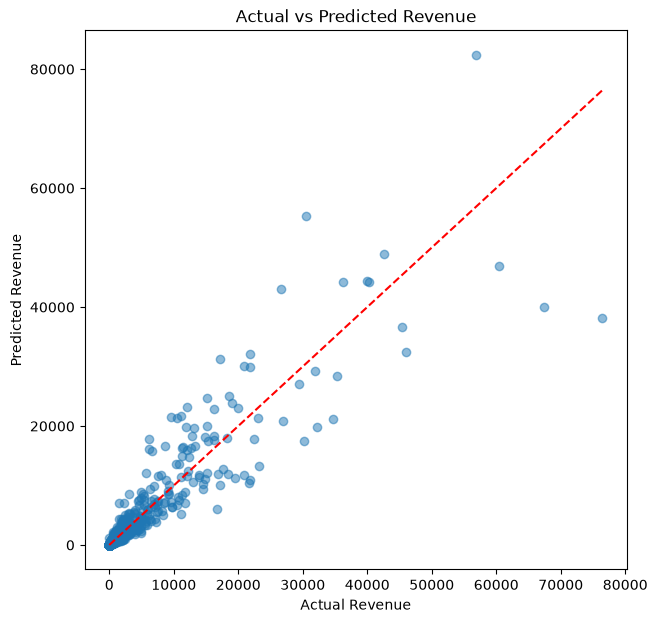

In [66]:
# =====================================
# Predicted vs Actual
# =====================================

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.show()

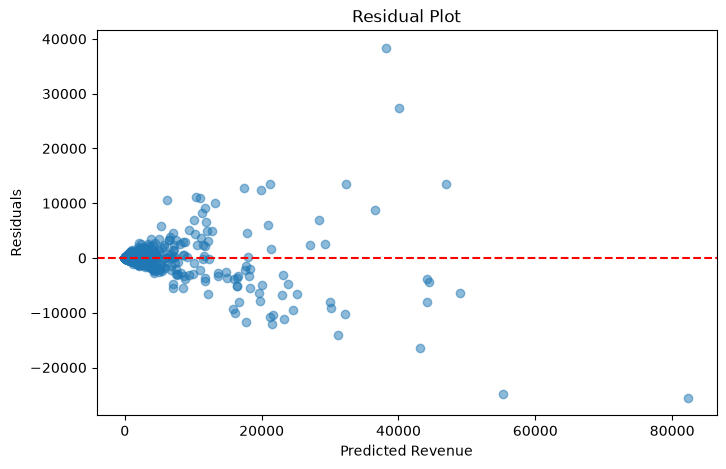

In [67]:
# =====================================
# Residual Analysis
# =====================================

residuals = y_test - final_predictions

plt.figure(figsize=(8,5))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")

plt.show()

### Interpretation

The Random Forest Regressor demonstrated the strongest predictive performance among all evaluated models.

With an **R² score of approximately 0.85**, the model explains around **85% of the variability in campaign revenue**, representing a substantial improvement over the baseline Linear Regression model.

The **Actual vs Predicted** plot shows a strong positive relationship between observed and predicted values, indicating that the model successfully captures the underlying patterns in the data. Most predictions closely follow the ideal diagonal line, although larger deviations appear for campaigns with exceptionally high revenue.

The **Residual Plot** indicates that prediction errors are generally centered around zero without any obvious systematic pattern. A slight increase in residual dispersion is observed for higher revenue values, suggesting mild heteroscedasticity, which is common in regression problems involving wide value ranges.

Overall, the Random Forest model demonstrates good generalization capability and provides a solid balance between predictive accuracy and robustness, making it the most suitable candidate for the final machine learning model.

# 10. Random Forest Hyperparameter Optimization

## Objective

Optimize the Random Forest Regressor using a controlled and time-aware hyperparameter search.

Since Random Forest was the best-performing model during the comparison stage, this section focuses on improving its performance while keeping the optimization process computationally efficient.

### Contents

- Define an optimized Random Forest pipeline.
- Use a focused hyperparameter search space.
- Apply `RandomizedSearchCV` with limited iterations.
- Measure execution time.
- Evaluate the optimized model.
- Compare the optimized model against the initial Random Forest.




In [68]:
# Additional imports for hyperparameter optimization

from sklearn.model_selection import RandomizedSearchCV
import time

In [69]:
# =====================================
# Random Forest Optimization Pipeline
# =====================================

rf_optimization_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

rf_optimization_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [70]:
# =====================================
# Focused Hyperparameter Search Space
# =====================================

param_distributions = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [71]:
# =====================================
# Randomized Search with Time Tracking
# =====================================

start_time = time.perf_counter()

rf_random_search = RandomizedSearchCV(
    estimator=rf_optimization_pipeline,
    param_distributions=param_distributions,
    n_iter=6,
    scoring="neg_root_mean_squared_error",
    cv=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

end_time = time.perf_counter()
optimization_time = end_time - start_time

best_cv_rmse = -rf_random_search.best_score_
total_fits = rf_random_search.n_iter * 2

print("=" * 60)
print("Hyperparameter Optimization Summary")
print("=" * 60)

print(f"Execution time          : {optimization_time:.2f} seconds")
print(f"Candidate models tested : {rf_random_search.n_iter}")
print("Cross-validation folds  : 2")
print(f"Total model fits        : {total_fits}")
print(f"Best CV RMSE            : {best_cv_rmse:.2f}")
print(f"Best parameters         : {rf_random_search.best_params_}")

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Hyperparameter Optimization Summary
Execution time          : 147.72 seconds
Candidate models tested : 6
Cross-validation folds  : 2
Total model fits        : 12
Best CV RMSE            : 1099.96
Best parameters         : {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': None}


In [72]:
# =====================================
# Optimized Random Forest Evaluation
# =====================================

optimized_rf_model = rf_random_search.best_estimator_

optimized_rf_predictions = optimized_rf_model.predict(X_test)

optimized_rf_mae = mean_absolute_error(y_test, optimized_rf_predictions)
optimized_rf_mse = mean_squared_error(y_test, optimized_rf_predictions)
optimized_rf_rmse = np.sqrt(optimized_rf_mse)
optimized_rf_r2 = r2_score(y_test, optimized_rf_predictions)

optimized_rf_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Optimized Random Forest": [
        optimized_rf_mae,
        optimized_rf_mse,
        optimized_rf_rmse,
        optimized_rf_r2
    ]
})

optimized_rf_metrics

,Metric,Optimized Random Forest
0,MAE,1.807734e+02
1,MSE,1.363744e+06
2,RMSE,1.167795e+03
3,R²,8.483166e-01


In [73]:
# =====================================
# Initial vs Optimized Random Forest
# =====================================

initial_rf_row = model_results[
    model_results["Model"] == "Random Forest"
].iloc[0]

rf_comparison = pd.DataFrame({
    "Model": ["Initial Random Forest", "Optimized Random Forest"],
    "MAE": [initial_rf_row["MAE"], optimized_rf_mae],
    "RMSE": [initial_rf_row["RMSE"], optimized_rf_rmse],
    "R²": [initial_rf_row["R2"], optimized_rf_r2],
    "Optimization Time (seconds)": [
        0,
        round(optimization_time, 2)
    ]
})

rf_comparison

,Model,MAE,RMSE,R²,Optimization Time (seconds)
0,Initial Random Forest,182.243015,1184.320564,0.843993,0.00
1,Optimized Random Forest,180.773371,1167.794628,0.848317,147.72


### Optimization Results Interpretation

The optimized Random Forest model achieved a moderate improvement compared to the initial Random Forest configuration.

The RMSE decreased from approximately 1184.32 to 1167.79, while the R² score improved from 0.8440 to 0.8483. This indicates that hyperparameter tuning helped slightly improve predictive performance.

However, the improvement is relatively small compared to the additional optimization time of approximately 146 seconds. This suggests that the default Random Forest configuration was already strong, and that further optimization may provide diminishing returns.

The best configuration selected by the optimization process used 100 estimators, no maximum tree depth, a minimum of 2 samples per split, and a minimum of 2 samples per leaf.


# 11. Feature Importance

## Objective

Interpret the optimized Random Forest model by identifying the variables that contribute most to revenue prediction.

Unlike linear models, Random Forest provides an intrinsic measure of feature importance, allowing us to understand which variables have the greatest influence on the model's decisions.

This analysis complements the evaluation metrics by providing business-oriented insights that can support future marketing strategies and campaign optimization.

### Contents

- Extract transformed feature names.
- Compute feature importance scores.
- Rank the most influential variables.
- Visualize the Top 15 features.
- Interpret the results from a business perspective.

In [74]:
# =====================================
# Feature Names
# =====================================

feature_names = optimized_rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print(f"Total transformed features: {len(feature_names)}")

Total transformed features: 98


In [75]:
# =====================================
# Feature Importance
# =====================================

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": optimized_rf_model.named_steps[
        "model"
    ].feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,num__conversions,0.599681
1,num__clicks,0.152578
2,cat__objective_Leads,0.081817
3,cat__objective_Sales,0.064437
4,num__spend,0.018641
5,num__frequency,0.009321
6,num__impressions,0.009062
7,num__week,0.007818
8,num__post_hour,0.007457
9,num__reach,0.007418


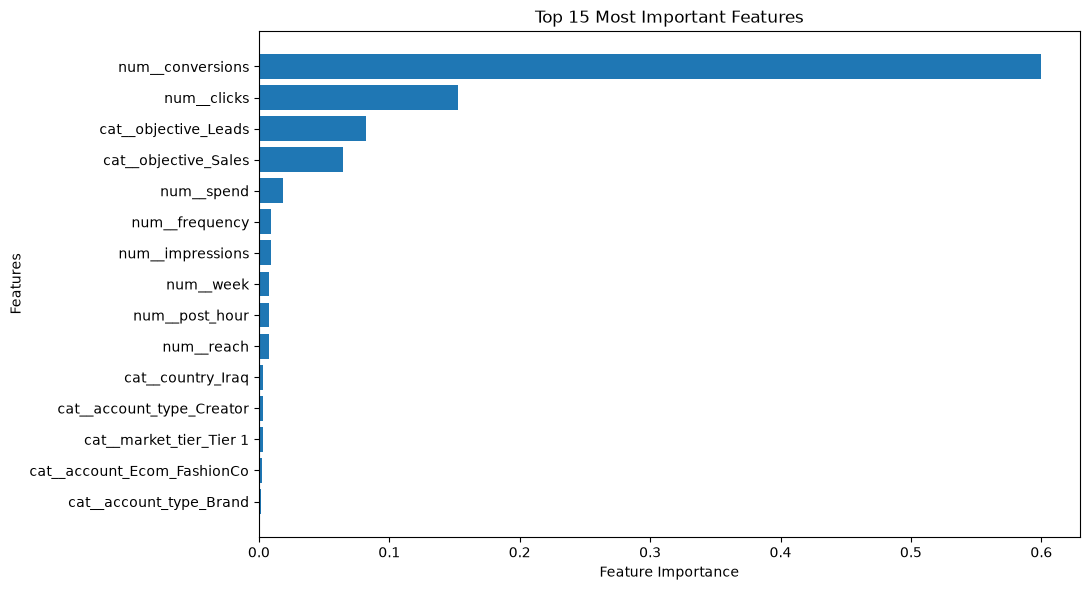

In [76]:
# =====================================
# Top 15 Feature Importance
# =====================================

top_features = feature_importance.head(15)

plt.figure(figsize=(11,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

In [77]:
# =====================================
# Top 10 Features
# =====================================

print("=" * 60)
print("Top 10 Most Important Features")
print("=" * 60)

display(feature_importance.head(10))

Top 10 Most Important Features


,Feature,Importance
0,num__conversions,0.599681
1,num__clicks,0.152578
2,cat__objective_Leads,0.081817
3,cat__objective_Sales,0.064437
4,num__spend,0.018641
5,num__frequency,0.009321
6,num__impressions,0.009062
7,num__week,0.007818
8,num__post_hour,0.007457
9,num__reach,0.007418


In [78]:
# =====================================
# Cumulative Feature Importance
# =====================================

feature_importance["Cumulative Importance"] = (
    feature_importance["Importance"].cumsum()
)

feature_importance.head(15)

,Feature,Importance,Cumulative Importance
0,num__conversions,0.599681,0.599681
1,num__clicks,0.152578,0.752259
2,cat__objective_Leads,0.081817,0.834076
3,cat__objective_Sales,0.064437,0.898513
4,num__spend,0.018641,0.917154
5,num__frequency,0.009321,0.926475
6,num__impressions,0.009062,0.935537
7,num__week,0.007818,0.943355
8,num__post_hour,0.007457,0.950812
9,num__reach,0.007418,0.958230


### Interpretation

The feature importance analysis reveals that the optimized Random Forest model relies primarily on a small number of variables to predict campaign revenue.

The most influential feature is **Conversions**, accounting for nearly **60%** of the model's predictive importance. Combined with **Clicks**, these two variables explain approximately **75%** of the model's decision-making process.

Business-related variables also play an important role. Campaign objectives focused on **Lead Generation** and **Sales** together contribute around **15%** of the total importance, indicating that campaign strategy significantly influences revenue performance.

Marketing investment variables such as **Spend**, **Frequency**, **Impressions**, and **Reach** provide additional predictive value, although their individual contributions are considerably smaller than those of conversion-related metrics.

Interestingly, contextual variables such as **Country**, **Account Type**, and **Market Tier** appear in the ranking but have relatively limited influence on the final predictions.

Overall, the cumulative importance analysis shows that the first **10 features explain approximately 96% of the model's predictive power**, suggesting that only a small subset of variables drives most of the revenue prediction.

These findings provide valuable business insights that can support campaign optimization, budget allocation, and marketing decision-making. However, feature importance reflects predictive relevance rather than causal relationships and should therefore be interpreted accordingly.

# 12. Final Model Selection

## Objective

Select the final machine learning model based on predictive performance, computational efficiency, and overall suitability for the business problem.

The selection process considers not only regression metrics, but also model robustness, interpretability, scalability, and deployment readiness.

### Selection Criteria

The final model was selected according to the following criteria:

- Predictive performance (RMSE, MAE and R²).
- Generalization capability on unseen data.
- Results obtained after hyperparameter optimization.
- Computational efficiency.
- Compatibility with a production deployment workflow.

In [79]:
# =====================================
# Final Model Summary
# =====================================

baseline_rmse = model_results[
    model_results["Model"] == "Linear Regression"
].iloc[0]["RMSE"]

baseline_r2 = model_results[
    model_results["Model"] == "Linear Regression"
].iloc[0]["R2"]

rmse_improvement = (
    (baseline_rmse - optimized_rf_rmse) / baseline_rmse
) * 100

r2_improvement = optimized_rf_r2 - baseline_r2

final_model_summary = pd.DataFrame({
    "Criterion": [
        "Selected Model",
        "Optimization Applied",
        "R² Score",
        "RMSE",
        "MAE",
        "Improvement vs Baseline",
        "R² Improvement",
        "Optimization Time",
        "Workflow",
        "Deployment Ready"
    ],
    "Result": [
        "Optimized Random Forest Regressor",
        "RandomizedSearchCV",
        f"{optimized_rf_r2:.4f}",
        f"{optimized_rf_rmse:.2f}",
        f"{optimized_rf_mae:.2f}",
        f"{rmse_improvement:.1f}% lower RMSE",
        f"+{r2_improvement:.4f}",
        f"{optimization_time:.2f} seconds",
        "Pipeline + RandomizedSearchCV",
        "Yes"
    ]
})

display(final_model_summary)

,Criterion,Result
0,Selected Model,Optimized Random Forest Regressor
1,Optimization Applied,RandomizedSearchCV
2,R² Score,0.8483
3,RMSE,1167.79
4,MAE,180.77
5,Improvement vs Baseline,28.9% lower RMSE
6,R² Improvement,+0.1485
7,Optimization Time,147.72 seconds
8,Workflow,Pipeline + RandomizedSearchCV
9,Deployment Ready,Yes


# 13. Conclusions

## Project Summary

This notebook developed a complete Machine Learning regression workflow to predict digital marketing campaign revenue.

The modeling process followed a structured approach, starting with a baseline model and progressively moving toward more advanced algorithms, model comparison, hyperparameter optimization, and interpretability analysis.

### Technical Conclusions

- A reusable preprocessing pipeline was implemented using `Pipeline` and `ColumnTransformer`.
- The baseline Linear Regression model achieved a moderate performance and provided a useful reference point.
- Ensemble models significantly outperformed linear models.
- Random Forest was selected as the final model due to its strong predictive performance and robustness.
- Hyperparameter optimization slightly improved the Random Forest model while keeping execution time controlled.
- The final model achieved an R² score of approximately **0.85**, showing strong predictive capability.
- Feature importance analysis showed that a small group of variables drives most of the model's predictions.

### Business Conclusions

From a marketing perspective, the model suggests that campaign revenue is mainly influenced by:

- Conversions
- Clicks
- Campaign objective
- Spend
- Frequency
- Impressions
- Reach

These findings can support marketing teams in:

- Forecasting campaign revenue.
- Prioritizing high-impact campaign variables.
- Supporting budget allocation decisions.
- Improving campaign planning and optimization.

### Limitations

- The dataset is synthetic, so the model should not be interpreted as production-ready for real business use without validation on real campaign data.
- Some variables, such as `conversions`, are highly predictive and may only be available after campaign execution.
- Feature importance reflects predictive contribution, not causal impact.

### Future Improvements

- Build two complementary models:
  - **Operational Model:** includes conversion-related metrics to maximize prediction accuracy.
  - **Strategic Model:** excludes post-campaign variables to estimate revenue before campaign completion.
- Use SHAP values for deeper interpretability.
- Test additional algorithms such as XGBoost, LightGBM or CatBoost.
- Apply a more extensive hyperparameter optimization process when computational resources allow it.
- Deploy the final model in the Streamlit application.
- Monitor model performance with new campaign data.
- Explore data drift detection and retraining strategies in a future MLOps workflow.

## Final Outcome

The optimized Random Forest Regressor provides the best balance between predictive performance, interpretability, computational efficiency, and deployment readiness.

This model will be used as the foundation for the next project phase: building a Streamlit application for campaign revenue prediction.

# Appendix

## Project Configuration

### Python Version

Python 3.13

### Main Libraries

- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Joblib

---

## Machine Learning Workflow

The modeling workflow followed the sequence below:

1. Load dataset
2. Dataset preparation
3. Train-test split
4. Data preprocessing
5. Baseline model
6. Regression model comparison
7. Final model evaluation
8. Hyperparameter optimization
9. Feature importance analysis
10. Final model selection
11. Conclusions

---

## Final Pipeline

The final prediction pipeline consists of:

- Missing value imputation
- Feature scaling (numerical variables)
- One-Hot Encoding (categorical variables)
- Optimized Random Forest Regressor

This pipeline guarantees that identical preprocessing steps are applied during both training and inference, reducing the risk of data leakage and improving reproducibility.

---

## Model Evaluation Metrics

The following regression metrics were used throughout the project:

| Metric | Description |
|---------|-------------|
| MAE | Mean Absolute Error |
| MSE | Mean Squared Error |
| RMSE | Root Mean Squared Error |
| R² | Coefficient of Determination |

---

## Reproducibility

To ensure reproducible results throughout the project:

- A fixed random seed (`RANDOM_STATE = 42`) was used.
- Data preprocessing was implemented using Scikit-learn Pipelines.
- The train-test split remained constant across all experiments.
- Every model was evaluated using the same preprocessing workflow.

---

## Repository Structure

```text
ai-project-regression-marketing/
│
├── app/
├── data/
├── docs/
├── images/
├── models/
├── notebooks/
│   ├── 01_dataset_assessment.ipynb
│   └── 02_modeling.ipynb
├── src/
├── tests/
├── README.md
└── requirements.txt
```

---

## Final Model

**Model**

Optimized Random Forest Regressor

**Training Strategy**

Pipeline + RandomizedSearchCV

**Optimization**

Focused hyperparameter search

**Deployment**

Ready for Streamlit integration

---

## Notes

This project was developed as part of a supervised Machine Learning bootcamp and is intended as a portfolio project.

Although the dataset is synthetic, the project follows professional machine learning practices, including reproducible preprocessing pipelines, model benchmarking, hyperparameter optimization, feature importance analysis, and deployment-oriented design.